# MCMC checks (2026-07-29)

Load and plot inference results for the **`claudetry1_vary-H0`** suite
(uniform mocks, linear $d_L$ uncertainty), following `2026-05-12_catalog_checks.ipynb`
and `2026-05-05_mcmc_checks.ipynb`.

Tags match `run_inf_loop.sh` / `generate_configs.py`:
`_mcmc_nw32_nsteps500_Dz0.003_claudetry1_vary-H0`.

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline
%load_ext autoreload
%autoreload 2

sys.path.append("../code")
import plotter

## Single run (seed 0, $\sigma_{dL} = 0$)

Point at the YAML under `configs/configs_inference/`. The HDF5 path is resolved inside `plotter.get_mcmc_data`.

In [2]:
dir_configs = "../configs/configs_inference"
tag_data = (
    "_uniform_seed0_ratioNgalNagn1_nside64_seedgw1000"
    "_fagn0.0_lambdaagn0.0_zmaxgw1.0_dLunclin0.0"
)
tag_inf = "_mcmc_nw32_nsteps500_Dz0.003_claudetry1_vary-H0"
fn_config_inference = f"{dir_configs}/config_inference{tag_data}{tag_inf}.yaml"
print(fn_config_inference)
print("exists:", os.path.isfile(fn_config_inference))

../configs/configs_inference/config_inference_uniform_seed0_ratioNgalNagn1_nside64_seedgw1000_fagn0.0_lambdaagn0.0_zmaxgw1.0_dLunclin0.0_mcmc_nw32_nsteps500_Dz0.003_claudetry1_vary-H0.yaml
exists: True


Loading inference results from ../results/inference/inference_results_uniform_seed0_ratioNgalNagn1_nside64_seedgw1000_fagn0.0_lambdaagn0.0_zmaxgw1.0_dLunclin0.0_mcmc_nw32_nsteps500_Dz0.003_claudetry1_vary-H0.h5
Only 1 parameter varied; using 1D marginalized plot instead of corner.


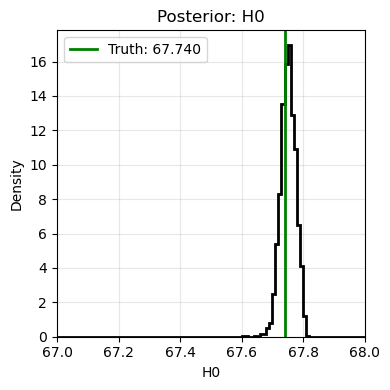

In [3]:
mcmc_data = plotter.get_mcmc_data(fn_config_inference)
plotter.plot_mcmc_contours(mcmc_data, range_min=67, range_max=68, bins=100)

In [4]:
dir_configs = "../configs/configs_inference"
tag_data = (
    "_uniform_seed0_ratioNgalNagn1_nside64_seedgw1000"
    "_fagn0.0_lambdaagn0.0_zmaxgw1.0_dLunclin0.0"
)
tag_inf = "_mcmc_nw32_nsteps500_Dz0.03_claudetry1_vary-H0"
fn_config_inference = f"{dir_configs}/config_inference{tag_data}{tag_inf}.yaml"
print(fn_config_inference)
print("exists:", os.path.isfile(fn_config_inference))

../configs/configs_inference/config_inference_uniform_seed0_ratioNgalNagn1_nside64_seedgw1000_fagn0.0_lambdaagn0.0_zmaxgw1.0_dLunclin0.0_mcmc_nw32_nsteps500_Dz0.03_claudetry1_vary-H0.yaml
exists: True


Loading inference results from ../results/inference/inference_results_uniform_seed0_ratioNgalNagn1_nside64_seedgw1000_fagn0.0_lambdaagn0.0_zmaxgw1.0_dLunclin0.0_mcmc_nw32_nsteps500_Dz0.03_claudetry1_vary-H0.h5
Only 1 parameter varied; using 1D marginalized plot instead of corner.


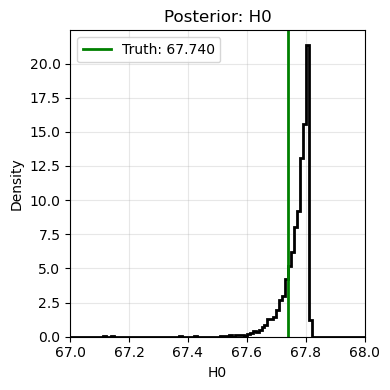

In [5]:
mcmc_data = plotter.get_mcmc_data(fn_config_inference)
plotter.plot_mcmc_contours(mcmc_data, range_min=67, range_max=68, bins=100)

## All seeds overlay (`Dz=0.003`, $\sigma_{dL}=0$)

Load MCMC results for mock seeds 0–9 and overplot 1D $H_0$ posteriors with distinct colors.

In [6]:
dir_configs = "../configs/configs_inference"
seeds = list(range(10))
tag_inf = "_mcmc_nw32_nsteps500_Dz0.003_claudetry1_vary-H0"

mcmc_data_arr = []
labels = []
missing = []
for seed in seeds:
    seedgw = 1000 + seed
    tag_data = (
        f"_uniform_seed{seed}_ratioNgalNagn1_nside64_seedgw{seedgw}"
        "_fagn0.0_lambdaagn0.0_zmaxgw1.0_dLunclin0.0"
    )
    fn_config_inference = f"{dir_configs}/config_inference{tag_data}{tag_inf}.yaml"
    if not os.path.isfile(fn_config_inference):
        missing.append((seed, "config"))
        continue
    try:
        mcmc_data = plotter.get_mcmc_data(fn_config_inference)
    except Exception as e:
        missing.append((seed, f"{type(e).__name__}: {e}"))
        continue
    mcmc_data_arr.append(mcmc_data)
    labels.append(f"seed {seed}")

print(f"Loaded {len(mcmc_data_arr)} / {len(seeds)} seeds")
if missing:
    print("Missing/failed:", missing)

Loading inference results from ../results/inference/inference_results_uniform_seed0_ratioNgalNagn1_nside64_seedgw1000_fagn0.0_lambdaagn0.0_zmaxgw1.0_dLunclin0.0_mcmc_nw32_nsteps500_Dz0.003_claudetry1_vary-H0.h5
Loading inference results from ../results/inference/inference_results_uniform_seed1_ratioNgalNagn1_nside64_seedgw1001_fagn0.0_lambdaagn0.0_zmaxgw1.0_dLunclin0.0_mcmc_nw32_nsteps500_Dz0.003_claudetry1_vary-H0.h5
Loading inference results from ../results/inference/inference_results_uniform_seed2_ratioNgalNagn1_nside64_seedgw1002_fagn0.0_lambdaagn0.0_zmaxgw1.0_dLunclin0.0_mcmc_nw32_nsteps500_Dz0.003_claudetry1_vary-H0.h5
Loading inference results from ../results/inference/inference_results_uniform_seed3_ratioNgalNagn1_nside64_seedgw1003_fagn0.0_lambdaagn0.0_zmaxgw1.0_dLunclin0.0_mcmc_nw32_nsteps500_Dz0.003_claudetry1_vary-H0.h5
Loading inference results from ../results/inference/inference_results_uniform_seed4_ratioNgalNagn1_nside64_seedgw1004_fagn0.0_lambdaagn0.0_zmaxgw1.0_dLuncli

Only 1 parameter varied; using 1D marginalized plot instead of corner.


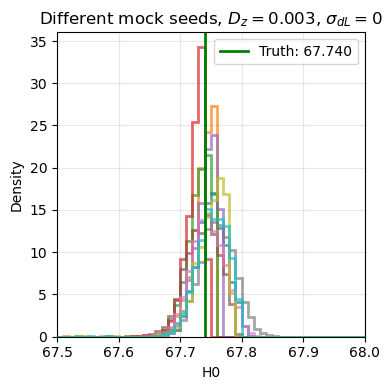

In [7]:
plotter.plot_mcmc_contours(
    mcmc_data_arr,
    labels=None,
    range_min=67.5,
    range_max=68,
    bins=50,
    title=r"Different mock seeds, $D_z=0.003$, $\sigma_{dL}=0$",
)

## Seed 0, vary $\sigma_{dL}$ (`Dz=0.003`)

Overlay $H_0$ posteriors for linear $d_L$ uncertainty factors $0.0$, $0.1$, $0.2$, $0.3$.

In [8]:
dir_configs = "../configs/configs_inference"
seed = 0
seedgw = 1000 + seed
dLunc_arr = [0.0, 0.02, 0.04, 0.06, 0.08, 0.1]#, 0.2, 0.3]
tag_inf = "_mcmc_nw32_nsteps500_Dz0.003_claudetry1_vary-H0"

mcmc_data_arr = []
labels = []
missing = []
for dLunc in dLunc_arr:
    tag_data = (
        f"_uniform_seed{seed}_ratioNgalNagn1_nside64_seedgw{seedgw}"
        f"_fagn0.0_lambdaagn0.0_zmaxgw1.0_dLunclin{dLunc}"
    )
    fn_config_inference = f"{dir_configs}/config_inference{tag_data}{tag_inf}.yaml"
    if not os.path.isfile(fn_config_inference):
        missing.append((dLunc, "config"))
        continue
    try:
        mcmc_data = plotter.get_mcmc_data(fn_config_inference)
    except Exception as e:
        missing.append((dLunc, f"{type(e).__name__}: {e}"))
        continue
    mcmc_data_arr.append(mcmc_data)
    labels.append(rf"$\sigma_{{dL}} = {dLunc}\, dL$")

print(f"Loaded {len(mcmc_data_arr)} / {len(dLunc_arr)} dLunc values")
if missing:
    print("Missing/failed:", missing)

Loading inference results from ../results/inference/inference_results_uniform_seed0_ratioNgalNagn1_nside64_seedgw1000_fagn0.0_lambdaagn0.0_zmaxgw1.0_dLunclin0.0_mcmc_nw32_nsteps500_Dz0.003_claudetry1_vary-H0.h5
Loading inference results from ../results/inference/inference_results_uniform_seed0_ratioNgalNagn1_nside64_seedgw1000_fagn0.0_lambdaagn0.0_zmaxgw1.0_dLunclin0.02_mcmc_nw32_nsteps500_Dz0.003_claudetry1_vary-H0.h5
Loading inference results from ../results/inference/inference_results_uniform_seed0_ratioNgalNagn1_nside64_seedgw1000_fagn0.0_lambdaagn0.0_zmaxgw1.0_dLunclin0.04_mcmc_nw32_nsteps500_Dz0.003_claudetry1_vary-H0.h5
Loading inference results from ../results/inference/inference_results_uniform_seed0_ratioNgalNagn1_nside64_seedgw1000_fagn0.0_lambdaagn0.0_zmaxgw1.0_dLunclin0.06_mcmc_nw32_nsteps500_Dz0.003_claudetry1_vary-H0.h5
Loading inference results from ../results/inference/inference_results_uniform_seed0_ratioNgalNagn1_nside64_seedgw1000_fagn0.0_lambdaagn0.0_zmaxgw1.0_dLun

Only 1 parameter varied; using 1D marginalized plot instead of corner.


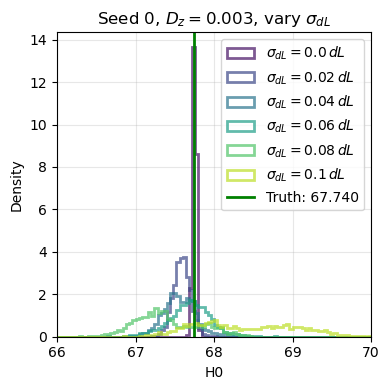

In [9]:
cmap = plt.get_cmap("viridis")
colors = [cmap(x) for x in np.linspace(0.05, 0.9, len(mcmc_data_arr))]

plotter.plot_mcmc_contours(
    mcmc_data_arr,
    labels=labels,
    colors=colors,
    range_min=66,
    range_max=70,
    bins=100,
    title=r"Seed 0, $D_z=0.003$, vary $\sigma_{dL}$",
)

## Seed 0, $\sigma_{dL}=0$, vary $D_z$

Compare `Dz=0.003` (existing) with new `Dz=0.001` and `Dz=0.0001`.


In [10]:
dir_configs = "../configs/configs_inference"
seed = 0
seedgw = 1000 + seed
dLunc = 0.0
Dz_arr = [0.03, 0.003, 0.001, 0.0001]

mcmc_data_arr = []
labels = []
missing = []
for Dz in Dz_arr:
    tag_data = (
        f"_uniform_seed{seed}_ratioNgalNagn1_nside64_seedgw{seedgw}"
        f"_fagn0.0_lambdaagn0.0_zmaxgw1.0_dLunclin{dLunc}"
    )
    tag_inf = f"_mcmc_nw32_nsteps500_Dz{Dz}_claudetry1_vary-H0"
    fn = f"{dir_configs}/config_inference{tag_data}{tag_inf}.yaml"
    if not os.path.isfile(fn):
        missing.append((Dz, "config"))
        continue
    try:
        mcmc_data_arr.append(plotter.get_mcmc_data(fn))
        labels.append(rf"$D_z = {Dz}$")
    except Exception as e:
        missing.append((Dz, f"{type(e).__name__}: {e}"))

print(f"Loaded {len(mcmc_data_arr)} / {len(Dz_arr)} Dz values")
if missing:
    print("Missing/failed:", missing)

Loading inference results from ../results/inference/inference_results_uniform_seed0_ratioNgalNagn1_nside64_seedgw1000_fagn0.0_lambdaagn0.0_zmaxgw1.0_dLunclin0.0_mcmc_nw32_nsteps500_Dz0.03_claudetry1_vary-H0.h5
Loading inference results from ../results/inference/inference_results_uniform_seed0_ratioNgalNagn1_nside64_seedgw1000_fagn0.0_lambdaagn0.0_zmaxgw1.0_dLunclin0.0_mcmc_nw32_nsteps500_Dz0.003_claudetry1_vary-H0.h5
Loading inference results from ../results/inference/inference_results_uniform_seed0_ratioNgalNagn1_nside64_seedgw1000_fagn0.0_lambdaagn0.0_zmaxgw1.0_dLunclin0.0_mcmc_nw32_nsteps500_Dz0.001_claudetry1_vary-H0.h5
Loading inference results from ../results/inference/inference_results_uniform_seed0_ratioNgalNagn1_nside64_seedgw1000_fagn0.0_lambdaagn0.0_zmaxgw1.0_dLunclin0.0_mcmc_nw32_nsteps500_Dz0.0001_claudetry1_vary-H0.h5
Loaded 4 / 4 Dz values


Only 1 parameter varied; using 1D marginalized plot instead of corner.


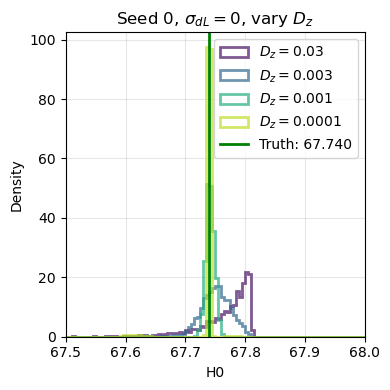

In [11]:
cmap = plt.get_cmap("viridis")
colors = [cmap(x) for x in np.linspace(0.05, 0.9, len(mcmc_data_arr))]

plotter.plot_mcmc_contours(
    mcmc_data_arr,
    labels=labels,
    colors=colors,
    range_min=67.5,
    range_max=68,
    bins=100,
    title=r"Seed 0, $\sigma_{dL}=0$, vary $D_z$",
)

Only 1 parameter varied; using 1D marginalized plot instead of corner.


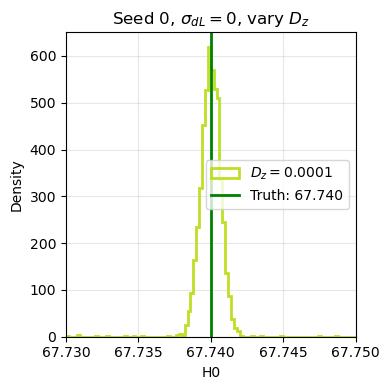

In [12]:
cmap = plt.get_cmap("viridis")
colors = [cmap(x) for x in np.linspace(0.05, 0.9, len(mcmc_data_arr))]

plotter.plot_mcmc_contours(
    mcmc_data_arr[-1:],
    labels=labels[-1:],
    colors=colors[-1:],
    range_min=67.73,
    range_max=67.75,
    bins=100,
    title=r"Seed 0, $\sigma_{dL}=0$, vary $D_z$",
)

## Infer $\alpha_{\rm AGN}$ across $(f_{\rm AGN}, \lambda_{\rm AGN})$ injections

Seed 0, $\sigma_{dL}=0$, and fiducial $D_z=0.001$. $H_0$ is fixed and only $\alpha_{\rm AGN}$ is varied.

Includes boundary injections $\alpha\simeq 0$ ($(f,\lambda)=(0,0)$) and $\alpha\simeq 1$ ($(1,0)$), for both **uniform** and **glass** mocks.


In [13]:
dir_configs = "../configs/configs_inference"
fagn_lambda_arr = [
    (0.0, 0.0),
    (0.0, 0.25),
    (0.25, 0.0),
    (0.25, 0.25),
    (0.0, 0.5),
    (0.5, 0.5),
    (1.0, 0.0),
]

def load_alpha_sweep(tag_mocktype="_uniform"):
    mcmc_data_arr = []
    labels = []
    missing = []
    for f_agn, lambda_agn in fagn_lambda_arr:
        if tag_mocktype == "_uniform":
            tag_data = (
                "_uniform_seed0_ratioNgalNagn1_nside64_seedgw1000"
                f"_fagn{f_agn}_lambdaagn{lambda_agn}_zmaxgw1.0_dLunclin0.0"
            )
        else:
            tag_data = (
                "_seed0_ratioNgalNagn1_bgal1.0_bagn1.0_nside64_seedgw1000"
                f"_fagn{f_agn}_lambdaagn{lambda_agn}_zmaxgw1.0_dLunclin0.0"
            )
        tag_inf = "_mcmc_nw32_nsteps500_Dz0.001_claudetry1_vary-alphaagn"
        fn = f"{dir_configs}/config_inference{tag_data}{tag_inf}.yaml"
        if not os.path.isfile(fn):
            missing.append(((f_agn, lambda_agn), "config"))
            continue
        try:
            data = plotter.get_mcmc_data(fn)
        except Exception as e:
            missing.append(((f_agn, lambda_agn), f"{type(e).__name__}: {e}"))
            continue

        truth = data["truth_alpha_agn"]
        samples = data["posterior_samples"][:, 0]
        q16, q50, q84 = np.percentile(samples, [16, 50, 84])
        mcmc_data_arr.append(data)
        labels.append(
            rf"$f={f_agn},\ \lambda={lambda_agn}$: "
            rf"$\alpha_{{\rm true}}={truth:.3f}$, "
            rf"$\alpha={q50:.3f}^{{+{q84-q50:.3f}}}_{{-{q50-q16:.3f}}}$"
        )
        print(
            f"[{tag_mocktype}] f={f_agn:.2f}, lambda={lambda_agn:.2f}: "
            f"truth={truth:.4f}, median={q50:.4f}, "
            f"68% CI=[{q16:.4f}, {q84:.4f}]"
        )
    print(f"Loaded {len(mcmc_data_arr)} / {len(fagn_lambda_arr)} ({tag_mocktype})")
    if missing:
        print("Missing/failed:", missing)
    return mcmc_data_arr, labels

alpha_uniform, labels_uniform = load_alpha_sweep("_uniform")
alpha_glass, labels_glass = load_alpha_sweep("_glass")


Loading inference results from ../results/inference/inference_results_uniform_seed0_ratioNgalNagn1_nside64_seedgw1000_fagn0.0_lambdaagn0.0_zmaxgw1.0_dLunclin0.0_mcmc_nw32_nsteps500_Dz0.001_claudetry1_vary-alphaagn.h5
[_uniform] f=0.00, lambda=0.00: truth=0.0000, median=0.0009, 68% CI=[0.0002, 0.0024]
Loading inference results from ../results/inference/inference_results_uniform_seed0_ratioNgalNagn1_nside64_seedgw1000_fagn0.0_lambdaagn0.25_zmaxgw1.0_dLunclin0.0_mcmc_nw32_nsteps500_Dz0.001_claudetry1_vary-alphaagn.h5
[_uniform] f=0.00, lambda=0.25: truth=0.2495, median=0.2330, 68% CI=[0.2156, 0.2512]
Loading inference results from ../results/inference/inference_results_uniform_seed0_ratioNgalNagn1_nside64_seedgw1000_fagn0.25_lambdaagn0.0_zmaxgw1.0_dLunclin0.0_mcmc_nw32_nsteps500_Dz0.001_claudetry1_vary-alphaagn.h5
[_uniform] f=0.25, lambda=0.00: truth=0.2500, median=0.2231, 68% CI=[0.2046, 0.2422]
Loading inference results from ../results/inference/inference_results_uniform_seed0_ratioNga

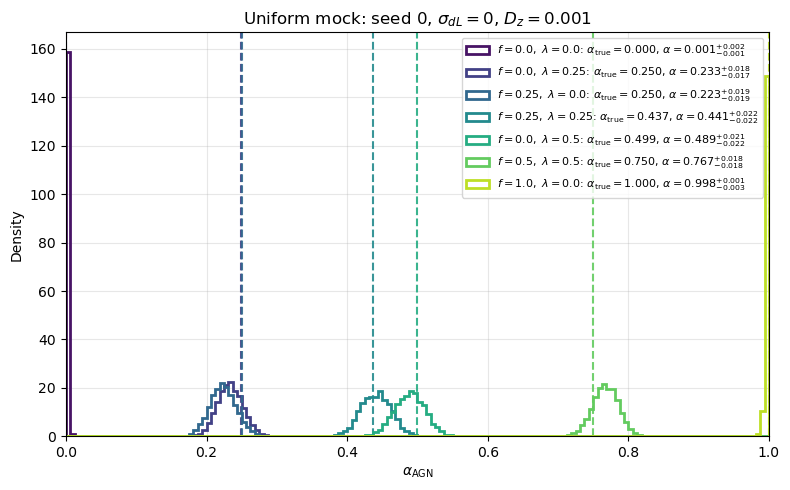

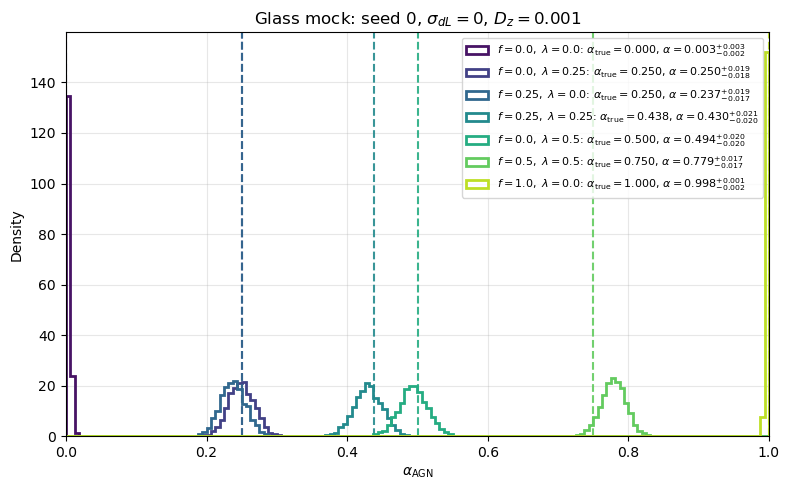

In [14]:
def plot_alpha_sweep(mcmc_data_arr, labels, title, xlim=(0.0, 1.0)):
    fig, ax = plt.subplots(figsize=(8, 5))
    cmap = plt.get_cmap("viridis")
    colors = [cmap(x) for x in np.linspace(0.05, 0.9, len(mcmc_data_arr))]
    bins = np.linspace(xlim[0], xlim[1], 161)

    for data, label, color in zip(mcmc_data_arr, labels, colors):
        samples = data["posterior_samples"][:, 0]
        truth = data["truth_alpha_agn"]
        ax.hist(
            samples,
            bins=bins,
            density=True,
            histtype="step",
            lw=2,
            color=color,
            label=label,
        )
        ax.axvline(truth, color=color, ls="--", lw=1.5, alpha=0.9)

    ax.set(
        xlabel=r"$\alpha_{\rm AGN}$",
        ylabel="Density",
        xlim=xlim,
        title=title,
    )
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
    plt.tight_layout()

plot_alpha_sweep(
    alpha_uniform,
    labels_uniform,
    r"Uniform mock: seed 0, $\sigma_{dL}=0$, $D_z=0.001$",
)
plot_alpha_sweep(
    alpha_glass,
    labels_glass,
    r"Glass mock: seed 0, $\sigma_{dL}=0$, $D_z=0.001$",
)


## Joint inference: $H_0$ + $\alpha_{\rm AGN}$

Seed 0, $\sigma_{dL}=0$, $D_z=0.001$. Both parameters free. Use `plotter.plot_mcmc_contours(mcmc_data)` for each $(f,\lambda)$ injection (uniform and glass).


In [15]:
dir_configs = "../configs/configs_inference"
fagn_lambda_arr = [
    (0.0, 0.0),
    (0.0, 0.25),
    (0.25, 0.0),
    (0.25, 0.25),
    (0.0, 0.5),
    (0.5, 0.5),
    (1.0, 0.0),
]

def load_joint_sweep(tag_mocktype="_uniform"):
    mcmc_data_arr = []
    labels = []
    missing = []
    for f_agn, lambda_agn in fagn_lambda_arr:
        if tag_mocktype == "_uniform":
            tag_data = (
                "_uniform_seed0_ratioNgalNagn1_nside64_seedgw1000"
                f"_fagn{f_agn}_lambdaagn{lambda_agn}_zmaxgw1.0_dLunclin0.0"
            )
        else:
            tag_data = (
                "_seed0_ratioNgalNagn1_bgal1.0_bagn1.0_nside64_seedgw1000"
                f"_fagn{f_agn}_lambdaagn{lambda_agn}_zmaxgw1.0_dLunclin0.0"
            )
        tag_inf = "_mcmc_nw32_nsteps500_Dz0.001_claudetry1_vary-H0-alphaagn"
        fn = f"{dir_configs}/config_inference{tag_data}{tag_inf}.yaml"
        if not os.path.isfile(fn):
            missing.append(((f_agn, lambda_agn), "config"))
            continue
        try:
            data = plotter.get_mcmc_data(fn)
        except Exception as e:
            missing.append(((f_agn, lambda_agn), f"{type(e).__name__}: {e}"))
            continue
        mcmc_data_arr.append(data)
        labels.append(
            rf"$f={f_agn},\ \lambda={lambda_agn}$ "
            rf"($\alpha_{{\rm true}}={data['truth_alpha_agn']:.3f}$)"
        )
        print(
            f"[{tag_mocktype}] f={f_agn}, l={lambda_agn}: "
            f"alpha_true={data['truth_alpha_agn']:.4f}, "
            f"params={data['labels']}"
        )
    print(f"Loaded {len(mcmc_data_arr)} / {len(fagn_lambda_arr)} ({tag_mocktype})")
    if missing:
        print("Missing/failed:", missing)
    return mcmc_data_arr, labels

joint_uniform, joint_labels_uniform = load_joint_sweep("_uniform")
joint_glass, joint_labels_glass = load_joint_sweep("_glass")


Loading inference results from ../results/inference/inference_results_uniform_seed0_ratioNgalNagn1_nside64_seedgw1000_fagn0.0_lambdaagn0.0_zmaxgw1.0_dLunclin0.0_mcmc_nw32_nsteps500_Dz0.001_claudetry1_vary-H0-alphaagn.h5
[_uniform] f=0.0, l=0.0: alpha_true=0.0000, params=['H0', 'alpha_agn']
Loading inference results from ../results/inference/inference_results_uniform_seed0_ratioNgalNagn1_nside64_seedgw1000_fagn0.0_lambdaagn0.25_zmaxgw1.0_dLunclin0.0_mcmc_nw32_nsteps500_Dz0.001_claudetry1_vary-H0-alphaagn.h5
[_uniform] f=0.0, l=0.25: alpha_true=0.2495, params=['H0', 'alpha_agn']
Loading inference results from ../results/inference/inference_results_uniform_seed0_ratioNgalNagn1_nside64_seedgw1000_fagn0.25_lambdaagn0.0_zmaxgw1.0_dLunclin0.0_mcmc_nw32_nsteps500_Dz0.001_claudetry1_vary-H0-alphaagn.h5
[_uniform] f=0.25, l=0.0: alpha_true=0.2500, params=['H0', 'alpha_agn']
Loading inference results from ../results/inference/inference_results_uniform_seed0_ratioNgalNagn1_nside64_seedgw1000_fagn0

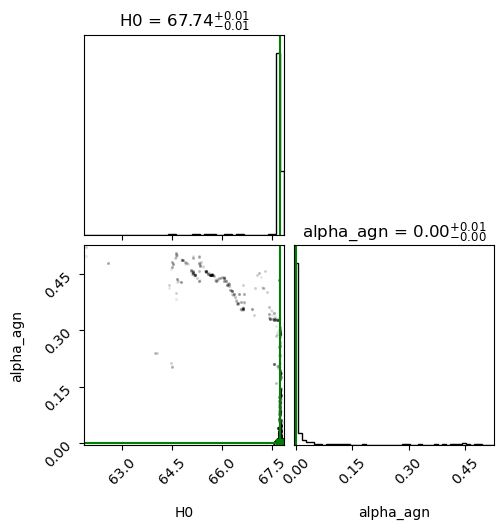

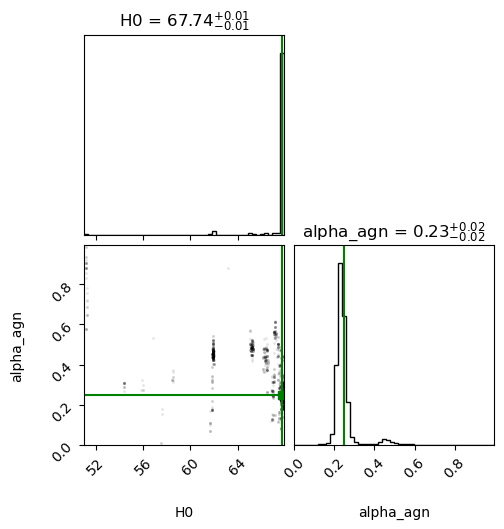

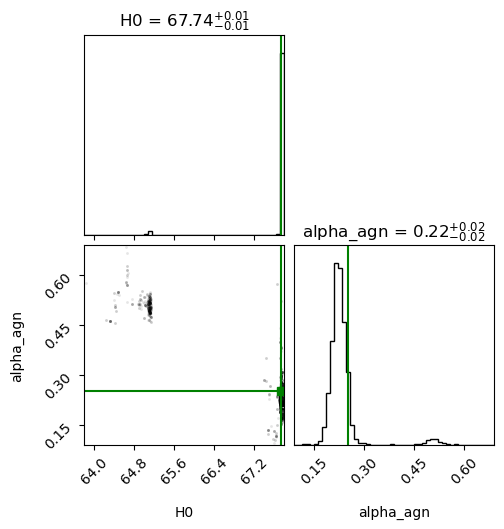

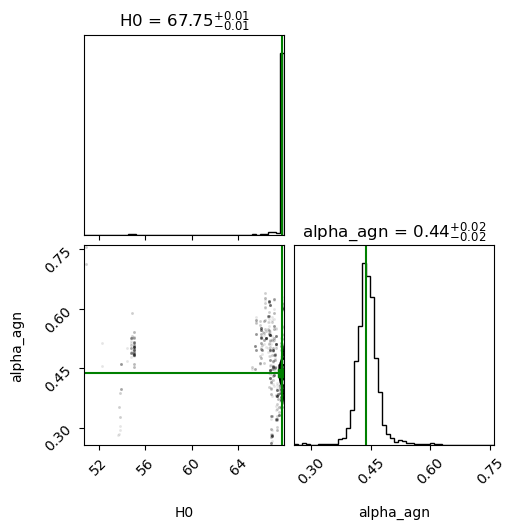

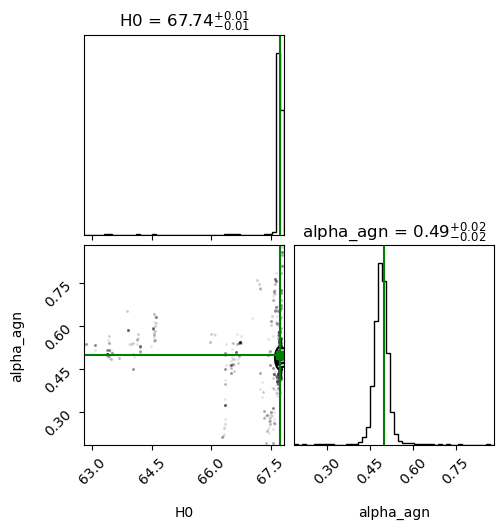

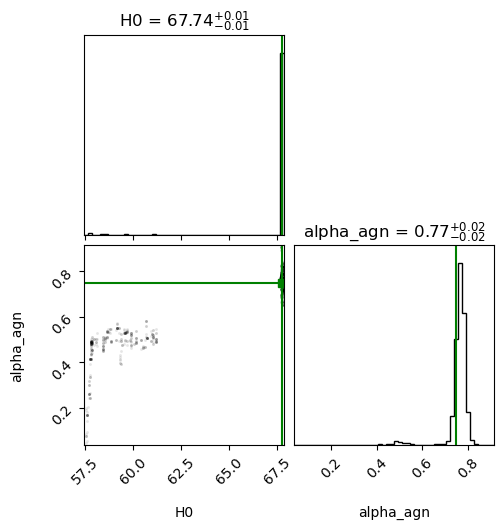

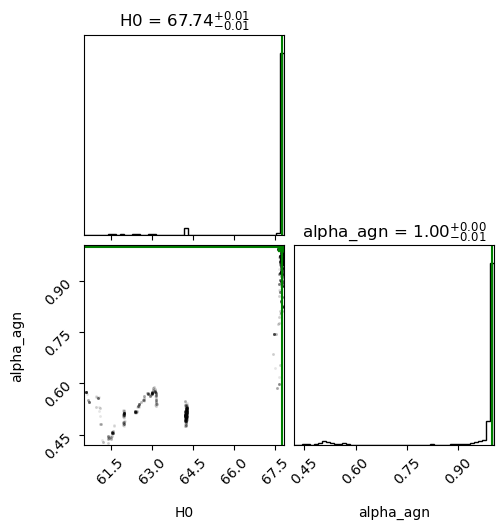

In [16]:
for mcmc_data in joint_uniform:
    plotter.plot_mcmc_contours(mcmc_data)


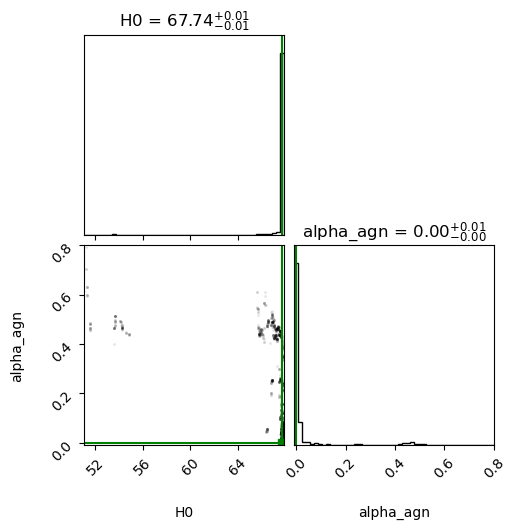

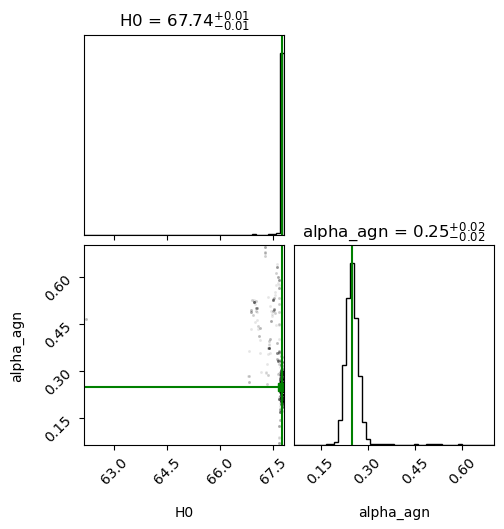

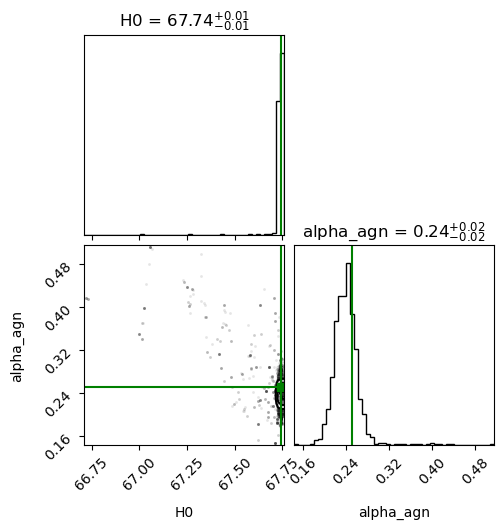

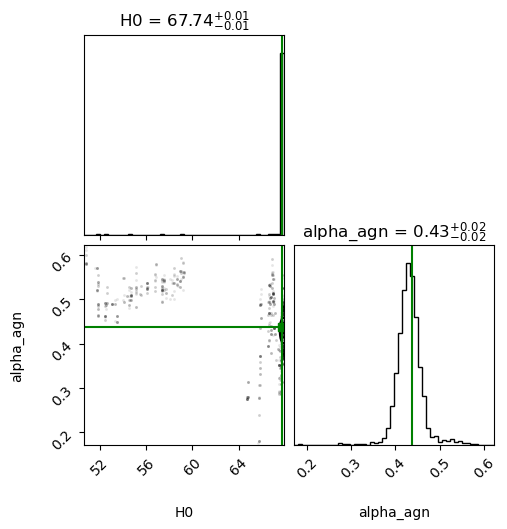

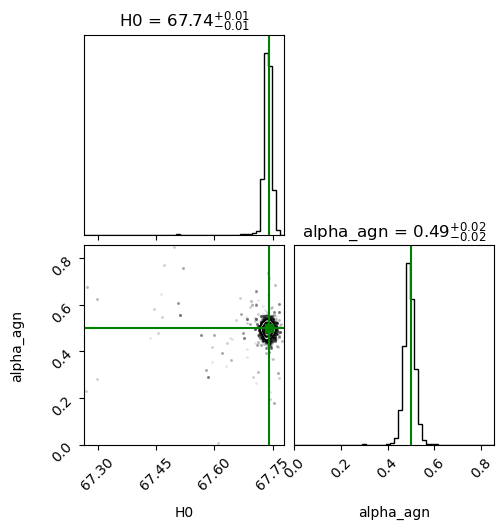

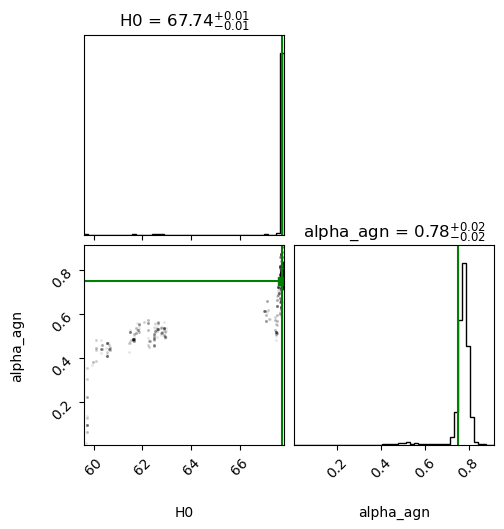

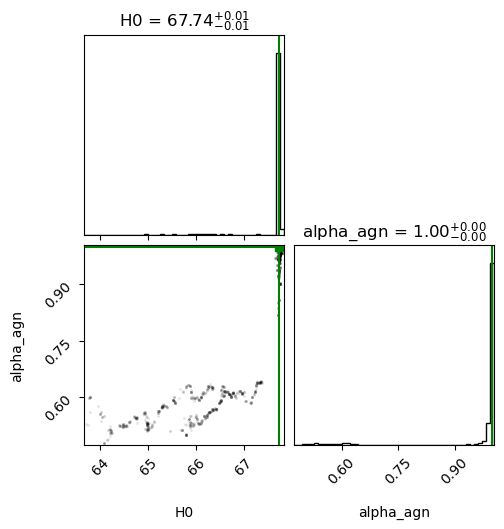

In [17]:
for mcmc_data in joint_glass:
    plotter.plot_mcmc_contours(mcmc_data)

## Glass mock seeds: $f=\lambda=0.25$, $\sigma_{dL}=0.05$, $D_z=0.001$

Joint $H_0$ + $\alpha_{\rm AGN}$ inference for mock seeds 0–5. Overlay all contours on one corner plot.

In [18]:
dir_configs = "../configs/configs_inference"
seeds = list(range(6))
dLunc = 0.05
Dz = 0.001
f_agn, lambda_agn = 0.25, 0.25

mcmc_glass_seeds = []
seed_labels = []
missing = []
for seed in seeds:
    seedgw = 1000 + seed
    tag = (
        f"_seed{seed}_ratioNgalNagn1_bgal1.0_bagn1.0_nside64_seedgw{seedgw}"
        f"_fagn{f_agn}_lambdaagn{lambda_agn}_zmaxgw1.0"
        f"_dLunclin{dLunc}_mcmc_nw32_nsteps500"
        f"_Dz{Dz}_claudetry1_vary-H0-alphaagn"
    )
    fn = f"{dir_configs}/config_inference{tag}.yaml"
    if not os.path.exists(fn):
        missing.append((seed, "config"))
        continue
    try:
        mcmc_glass_seeds.append(plotter.get_mcmc_data(fn))
        seed_labels.append(f"seed {seed}")
    except Exception as e:
        missing.append((seed, f"{type(e).__name__}: {e}"))

print(f"Loaded {len(mcmc_glass_seeds)} / {len(seeds)} seeds")
if missing:
    print("Missing:")
    for seed, reason in missing:
        print(f"  seed {seed}: {reason}")


Loading inference results from ../results/inference/inference_results_seed0_ratioNgalNagn1_bgal1.0_bagn1.0_nside64_seedgw1000_fagn0.25_lambdaagn0.25_zmaxgw1.0_dLunclin0.05_mcmc_nw32_nsteps500_Dz0.001_claudetry1_vary-H0-alphaagn.h5
Loading inference results from ../results/inference/inference_results_seed1_ratioNgalNagn1_bgal1.0_bagn1.0_nside64_seedgw1001_fagn0.25_lambdaagn0.25_zmaxgw1.0_dLunclin0.05_mcmc_nw32_nsteps500_Dz0.001_claudetry1_vary-H0-alphaagn.h5
Loading inference results from ../results/inference/inference_results_seed2_ratioNgalNagn1_bgal1.0_bagn1.0_nside64_seedgw1002_fagn0.25_lambdaagn0.25_zmaxgw1.0_dLunclin0.05_mcmc_nw32_nsteps500_Dz0.001_claudetry1_vary-H0-alphaagn.h5
Loading inference results from ../results/inference/inference_results_seed3_ratioNgalNagn1_bgal1.0_bagn1.0_nside64_seedgw1003_fagn0.25_lambdaagn0.25_zmaxgw1.0_dLunclin0.05_mcmc_nw32_nsteps500_Dz0.001_claudetry1_vary-H0-alphaagn.h5
Loading inference results from ../results/inference/inference_results_seed4_

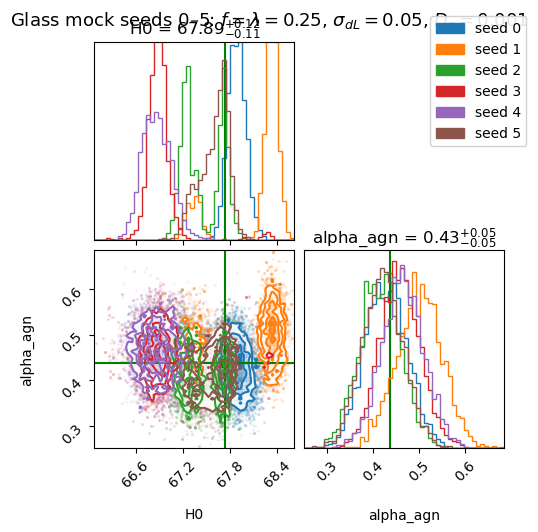

In [19]:
plotter.plot_mcmc_contours(
    mcmc_glass_seeds,
    labels=seed_labels,
    title=(
        r"Glass mock seeds 0–5: $f=\lambda=0.25$, "
        r"$\sigma_{dL}=0.05$, $D_z=0.001$"
    ),
)
